# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 21     |  |
| :-------------|:-------------|
| Lucas Everstein| 16291392 |
| Luuc Leclercq| 6578136 |
| Adam Echant Hamdioui|6563031  |
|---|---|
| Werkende condensator | 12:45 |
| Metingen uit de zelfgemaakte sensor | 15:00 |
| Beginnen met testen | 15:15 |
| Data verwerkt, geplot en gefit| 16:45 |
| Finaliseren| 17:15 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| n.v.t. |
| Pauze 1| 12:45 |
| Pauze 2| 15:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
![schets student 1](FotoCheck3.jpg)


In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt

def Capaciteit_Theorie(eps_0, eps_r, A, d):
    C_theorie = (eps_0*eps_r*A)/d
    return C_theorie
def Capaciteit_Omschrijving(R, A, f, A_out):
    C_Omschrijving = (A_out)/(2*np.pi*f*R*A)
    return C_Omschrijving
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [Capaciteit_Theorie(8.854e-12,2.0, 0.01,0.001)*10e13, Capaciteit_Omschrijving(10e3, 16, 10e5, 1.6)*10e13]
print(f"Berekende capaciteit plaatcondensator groep 21 is {C[1]:.1f} pF")



Berekende capaciteit plaatcondensator groep 21 is 159.2 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](Condensator.jpg)
![scope meting 2](MeetingCondensator.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 21| 177pF |1.56V | 1.6V |159pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](FotoCheck3Beter.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die X meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](BetereSchets.jpg)

[ 2  4  6  8 10 12 14 16 18]
3.580986219567645e-11


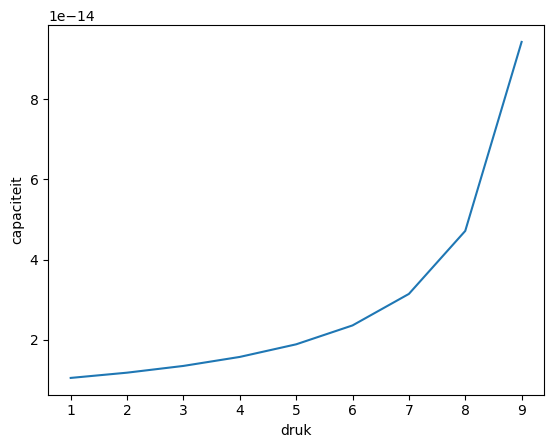

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def Druk(x, k):
    return k*x
#def A_out(f, R, C, A):
#    return 2*np.pi*C*A*R*f
Test_array = Druk(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 2)
print(Test_array)
#print(A_out(10e5, 10e3, 37.7e-12, 0.01))
print(Capaciteit_Omschrijving(1000, 16, 100000, 0.360))
#dit is een heel erg versimpelde weergave van wat we verwachte als grafiek te zien. We gebruiken een arbitraire testarray van 1 tot 9 om de ingedrukte afstand procentueel uit te drukken.
#Hiermee kunnen we een verhouding qua kracht maken om te zorgen dat we daarmee een inschatting kunnen doen voor LTSpice
plt.figure()
plt.plot(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]), Capaciteit_Theorie(8.854e-12, 1.065, 0.01, 10-(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]))))
plt.xlabel("druk")
plt.ylabel("capaciteit")
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 35.8 | 358 |
| gemiddelde capaciteit| 124 |1224 |
| maximale capaciteit| 249 |2470 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Opstelling.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

[2.89735675e-03 3.64323459e+01]


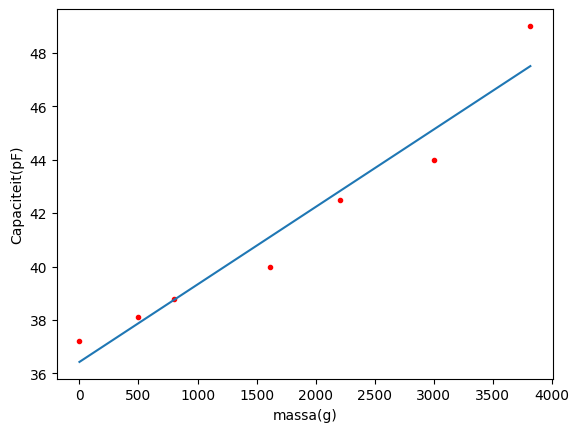

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

Gewicht = np.array([0, 491.9, 800, 1615.8, 2203.1, 3003.1, 3818.9])
Capaciteit = np.array([37.2,38.1, 38.8, 40.0, 42.5, 44.0, 49])
u_m = 5
u_C = 0.3
def Fit_Func(m, k, b):
    return k*m+ b
#(8.854e-12*1.065*0.04/(0.015-((9.81*m)/k)))
#Capaciteit_fit = Capaciteit*10e-12
val, cov = curve_fit(Fit_Func, Gewicht, Capaciteit)
print(val)
plt.figure()
plt.plot(Gewicht, Capaciteit, 'r.', label="test")
plt.plot(Gewicht, Fit_Func(Gewicht, val[0], val[1]))
plt.xlabel("massa(g)")
plt.ylabel("Capaciteit(pF)")
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Een rigide geleidende plaat, die nu gemaakt is is van aan elkaar getapte kartonnen plaatjes waar aluminium aan is getapet. Hierdoor kon deze buigen en is de afstand tussen de twee platen niet volledig uniform. Om dit korte termijn op te lossen hebben wij hier rigide houten planken op(en onder) gelegd waardoor de doorbuigen verwaarloosbaar was, maar hierdoor is onze sensor op een hoger gewicht geijkt waardoor de precieze minder goed is.
* Uniforme pons, We hadden niet genoeg lage spons om de volledige plaat te bedekken dus hebben we op alle krachtpunten gelegd, maar hierdoor heb je ook wel een deel lucht tussen je platen zit en je niet volledig de epsilon van je pons kan gebruiken. Het is te verwachten dat dit een klein effect heeft maar het zal ook hebben met hoe uniform de spons ingeduwd wordt door de kracht.


## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](Opstelling.jpg.jpeg)

[  5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.  70.
  75.  80.  85.  90.  95. 100.]
[ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140.
 150. 160. 170. 180. 190. 200.]


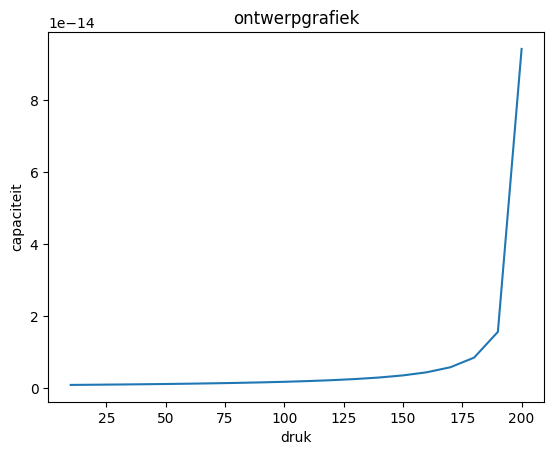

[0.00075 0.0015  0.00225 0.003   0.00375 0.0045  0.00525 0.006   0.00675
 0.0075  0.00825 0.009   0.00975 0.0105  0.01125 0.012   0.01275 0.0135
 0.01425 0.015  ]


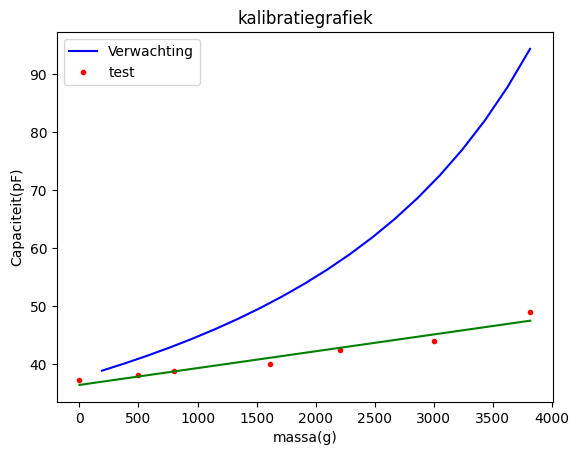

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def Druk(x, k):#Kracht van een veer
    return k*x

x_Verwachting = np.linspace(5, 100, 20) #Ik heb dit zo gedaan om het als een soort van verdeling te nemen
print(x_Verwachting)
Test_array = Druk(x_Verwachting, 2) #willekeurige waarde voor k
print(Test_array)

#dit is een heel erg versimpelde weergave van wat we verwachte als grafiek te zien. We gebruiken een arbitraire testarray van 1 tot 9 om de ingedrukte afstand procentueel uit te drukken.
#Hiermee kunnen we een verhouding qua kracht maken om te zorgen dat we daarmee een inschatting kunnen doen voor LTSpice


plt.figure()
plt.title("ontwerpgrafiek")
plt.plot(Test_array, Capaciteit_Theorie(8.854e-12, 1.065, 0.01, 101-(x_Verwachting))) #100-(x_Verwachting) is om weer te geven wat de dikte is in procenten
plt.xlabel("druk")
plt.ylabel("capaciteit")
plt.show()
#Uit de ontwerpgrafiek kwam een verband dat we later achter kwamen dat niet klopte, maar toen waren we in tijdsnood en hebben we deze niet aangepast
Test_Verwachting = (x_Verwachting/100)*0.015 #Hier heb ik de procentuele weergave keer de rustuitwijking gedaan. Hiermee verwachten we een weergave die qua grote klopt
x_Verwachting2 = (x_Verwachting/100)*3815.9 #Hier heb ik de procentuele weergave keer de maximale massa gedaan. Hiermee verwachten we een weergave die qua grote klopt
print(Test_Verwachting)
Test_Capaciteit = Capaciteit_Theorie(8.854e-12, 1.065, 0.01, (0.025-(Test_Verwachting)))*10e12

plt.figure()
plt.title("kalibratiegrafiek")
plt.plot(x_Verwachting2, Test_Capaciteit, 'b', label="Verwachting")
plt.plot(Gewicht, Capaciteit, 'r.', label="test")
plt.plot(Gewicht, Fit_Func(Gewicht, val[0], val[1]), 'g')
plt.xlabel("massa(g)")
plt.ylabel("Capaciteit(pF)")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

 We hebben een linear verband gevonden op basis van de aanname dat de spons zich gedraagd als een veer met een lineare kracht-uitwijking verhouding. Echter is het op basis van ervaring te stellen dat een gemiddelde spons zich niet zo gedraagd als je kan bedenken dat als je een spons twee keer zo hard indrukt deze niet twee keer zo ver ingedrukt wordt. Het is te verwachten dat er een exponentieel verband is dat deze verhouding zou beschrijven waarmee je een fit kan krijgen die accurater is dan de huidige fit. \
 Ook is een spons niet echt goed linear te voorspellen door mogelijke luchtbubbels. \
 Los van deze punten is een arduino überhaubt niet de allerbeste tool om zoiets te meten aangezien bij waardes onder de 1V de arduino niet een heel accurate waarde geeft en als maximale waarde een input van 5V kan hebben. Dit zorgt voor een hele kleine effectieve range

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![](Condensator.jpg)
![](MeetingCondensator.jpg)

3.580986219567645e-11


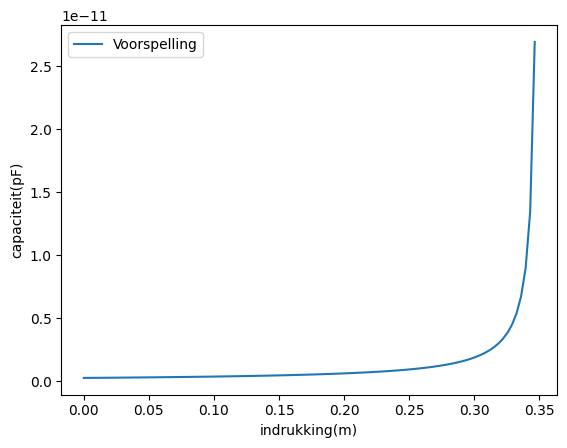

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def Druk(x, k):
    return k*x
#def A_out(f, R, C, A):
#    return 2*np.pi*C*A*R*f
Test_array = Druk(np.array(np.linspace(10, 100)), 2)
#print(A_out(10e5, 10e3, 37.7e-12, 0.01))
print(Capaciteit_Omschrijving(1000, 16, 100000, 0.360))
#dit is een heel erg versimpelde weergave van wat we verwachte als grafiek te zien. We gebruiken een arbitraire testarray van 1 tot 9 om de ingedrukte afstand procentueel uit te drukken.
#Hiermee kunnen we een verhouding qua kracht maken om te zorgen dat we daarmee een inschatting kunnen doen voor LTSpice
plt.figure()
plt.plot(np.array(np.linspace(0, 9.9, 100)*0.035), Capaciteit_Theorie(8.854e-12, 1.065, 0.01, 0.035*(10-(np.array(np.linspace(0, 9.9, 100))))), label="Voorspelling")
plt.legend()
plt.xlabel("indrukking(m)")
plt.ylabel("capaciteit(pF)")
plt.show()

Voor leerdoel 2:

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 35.8 | 358 |
| gemiddelde capaciteit| 124 |1224 |
| maximale capaciteit| 249 |2470 |

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](Opstelling.jpg.jpeg)

Hier hebben we niet heel veel foto's voor of al ingevulde cellen. Wel is het te halen uit onze fix voor een originele meetwaarde die niet voldeed. Origineel hadden we de twee plaatjes met een oppervlakte van 10cm x 10cm gewoon met een spons ertussen gebruikt, maar toen onze gemeten capaciteit te laag was hadden we bedacht op vier kartonnen plaatjes van 10cm x 10cm aanelkaar te tapen en daar aluminiumfolie over te tapen om zo het overlappende oppervlakte te viervoudigen. Hieruit blijkt dat we zowel begrip hadden over de fysica en wat allemaal invloed had op onze uiteindelijke meting en welke parameters er nog te beinvloeden waren en over weg kunnen met een meting, ook als het resultaat meevalt.

Voor leerdoel 3:

## Opdracht 7: Plot de kalibratiegrafiek.

[2.89735675e-03 3.64323459e+01]


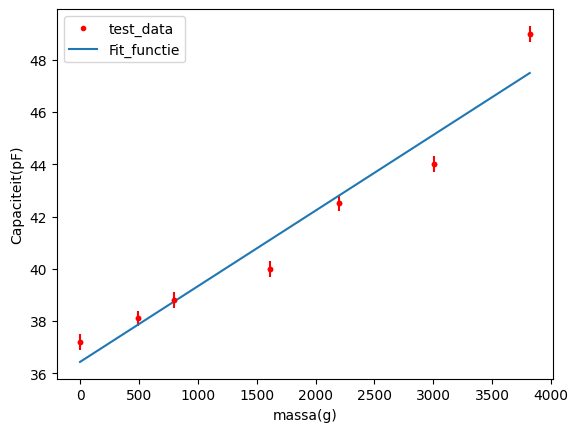

In [7]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

Gewicht = np.array([0, 491.9, 800, 1615.8, 2203.1, 3003.1, 3818.9])
Capaciteit = np.array([37.2,38.1, 38.8, 40.0, 42.5, 44.0, 49])
u_m = 5
u_C = 0.3
#Dit is gefit op basis van een linear verband. Dit is gedaan aangezien ik had aangenomen dat de spons zich zou gedrageb als een veer.
def Fit_Func(m, k, b):
    return k*m+ b
#(8.854e-12*1.065*0.04/(0.015-((9.81*m)/k)))
#Capaciteit_fit = Capaciteit*10e-12
val, cov = curve_fit(Fit_Func, Gewicht, Capaciteit)
print(val)
plt.figure()
plt.errorbar(Gewicht, Capaciteit, u_C, u_m, 'r.')
plt.plot(Gewicht, Capaciteit, 'r.', label="test_data")
plt.plot(Gewicht, Fit_Func(Gewicht, val[0], val[1]), label="Fit_functie")
plt.xlabel("massa(g)")
plt.ylabel("Capaciteit(pF)")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

 We hebben een linear verband gevonden op basis van de aanname dat de spons zich gedraagd als een veer met een lineare kracht-uitwijking verhouding. Echter is het op basis van ervaring te stellen dat een gemiddelde spons zich niet zo gedraagd als je kan bedenken dat als je een spons twee keer zo hard indrukt deze niet twee keer zo ver ingedrukt wordt. Het is te verwachten dat er een exponentieel verband is dat deze verhouding zou beschrijven waarmee je een fit kan krijgen die accurater is dan de huidige fit. \
 Ook is een spons niet echt goed linear te voorspellen door mogelijke luchtbubbels. \
 Los van deze punten is een arduino überhaubt niet de allerbeste tool om zoiets te meten aangezien bij waardes onder de 1V de arduino niet een heel accurate waarde geeft en als maximale waarde een input van 5V kan hebben. Dit zorgt voor een hele kleine effectieve range